In [1]:
# T01_01.py
import pandas as pd
import numpy as np

df = pd.DataFrame({
 'order_time': ['2025-01-15 10:30:00', '2025-03-22 19:15:30', '2026-07-07 02:05:55']}) # ①

df['order_time'] = pd.to_datetime(df['order_time']) # ②
df.info()

df['year'] = df['order_time'].dt.year # ③
df['month'] = df['order_time'].dt.month # ③
df['day'] = df['order_time'].dt.day # ③
df['hour'] = df['order_time'].dt.hour # ③
df['minute'] = df['order_time'].dt.minute # ③
df['second'] = df['order_time'].dt.second # ③
df['weekday'] = df['order_time'].dt.weekday # ④
df['day_name'] = df['order_time'].dt.day_name() # ⑤
df['quarter'] = df['order_time'].dt.quarter # ⑥
df['weekofyear'] = df['order_time'].dt.isocalendar().week # ⑦

print(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   order_time  3 non-null      datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 156.0 bytes
           order_time  year  month  day  hour  minute  second  weekday  \
0 2025-01-15 10:30:00  2025      1   15    10      30       0        2   
1 2025-03-22 19:15:30  2025      3   22    19      15      30        5   
2 2026-07-07 02:05:55  2026      7    7     2       5      55        1   

    day_name  quarter  weekofyear  
0  Wednesday        1           3  
1   Saturday        1          12  
2    Tuesday        3          28  


In [2]:
# T01_02.py
import sklearn # ①
import numpy as np # ②
import pandas as pd # ③
import matplotlib # ④
import seaborn as sns # ⑤

print(f"scikit-learn: {sklearn.__version__}") # ⑥
print(f"NumPy: {np.__version__}") # ⑦
print(f"Pandas: {pd.__version__}") # ⑧
print(f"Matplotlib: {matplotlib.__version__}") # ⑨
print(f"Seaborn: {sns.__version__}") # ⑩

scikit-learn: 1.6.1
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
Seaborn: 0.13.2


In [3]:
# T01_03.py
import pandas as pd
import numpy as np

# 타이타닉 데이터셋 로드
df = pd.read_csv(
 'https://raw.githubusercontent.com/' +
 'ajaedevs/python-machine-learning/' +
 'main/data/titanic.csv'
) # ①

# 1. 데이터의 첫 5개 행 확인(일부 데이터 확인)
print(df.head()) # ②

# 2. 데이터의 요약 정보 확인(전체 구조 파악)
df.info() # ③

# 3. 데이터의 기술 통계량 확인(숫자와 문자를 모두 포함)
print(df.describe(include='all')) # ④

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [4]:
# T01_04.py
import pandas as pd
import numpy as np

# 타이타닉 데이터셋 로드
df = pd.read_csv(
 'https://raw.githubusercontent.com/' +
 'ajaedevs/python-machine-learning/' +
 'main/data/titanic.csv'
)

# Pclass 컬럼의 고유 값 확인
print(f"Pclass의 고유 값: {df['Pclass'].unique()}") # ①

# Embarked 컬럼의 고유 값과 각 값의 개수 확인
print(df['Embarked'].value_counts()) # ②

Pclass의 고유 값: [3 1 2]
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [5]:
# T01_05.py
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer() # ①
X = cancer.data # ②
y = cancer.target # ③

# 데이터 시간 순서 보존(shuffle=False) 및 드리프트(Data Drift) 시뮬레이션 적용
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False,
random_state=42)
X_test_corrupted = X_test.copy()
X_test_corrupted[:, :10] *= 1.5 # ④

# 전체 데이터를 먼저 스케일링한 후 분리
scaler_leaky = StandardScaler() # ⑤
X_scaled_leaky = scaler_leaky.fit_transform(np.vstack([X_train, X_test_corrupted])) # ⑥
X_train_leaky, X_test_leaky = X_scaled_leaky[:len(X_train)], X_scaled_leaky[len(X_train):]
y_train_leaky, y_test_leaky = y_train, y_test

# 모델 학습 및 평가
model1 = LogisticRegression(random_state=42, max_iter=1000) # ⑦
model1.fit(X_train_leaky, y_train_leaky) # ⑧
pred1 = model1.predict(X_test_leaky) # ⑨
accuracy1 = accuracy_score(y_test_leaky, pred1) # ⑩
print(f"데이터 유출 시 모델 정확도: {accuracy1:.4f}") # ⑪

데이터 유출 시 모델 정확도: 0.8421


In [6]:
# T01_06.py
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

cancer = load_breast_cancer() # ①
X = cancer.data # ②
y = cancer.target # ③

# 데이터 시간 순서 보존(shuffle=False) 및 드리프트(Data Drift) 시뮬레이션 적용
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False,
random_state=42)
X_test_corrupted = X_test.copy()
X_test_corrupted[:, :10] *= 1.5 # ④

# 파이프라인을 사용하여 전처리와 모델을 묶음
pipe = Pipeline([('scaler', StandardScaler()),
('classifier', LogisticRegression(random_state=42, max_iter=1000))]) # ⑤

# 파이프라인 학습 및 평가
pipe.fit(X_train, y_train) # ⑥
pred2 = pipe.predict(X_test_corrupted) # ⑦
accuracy2 = accuracy_score(y_test, pred2) # ⑧
print(f"올바른 방법의 모델 정확도: {accuracy2:.4f}") # ⑨

올바른 방법의 모델 정확도: 0.7895


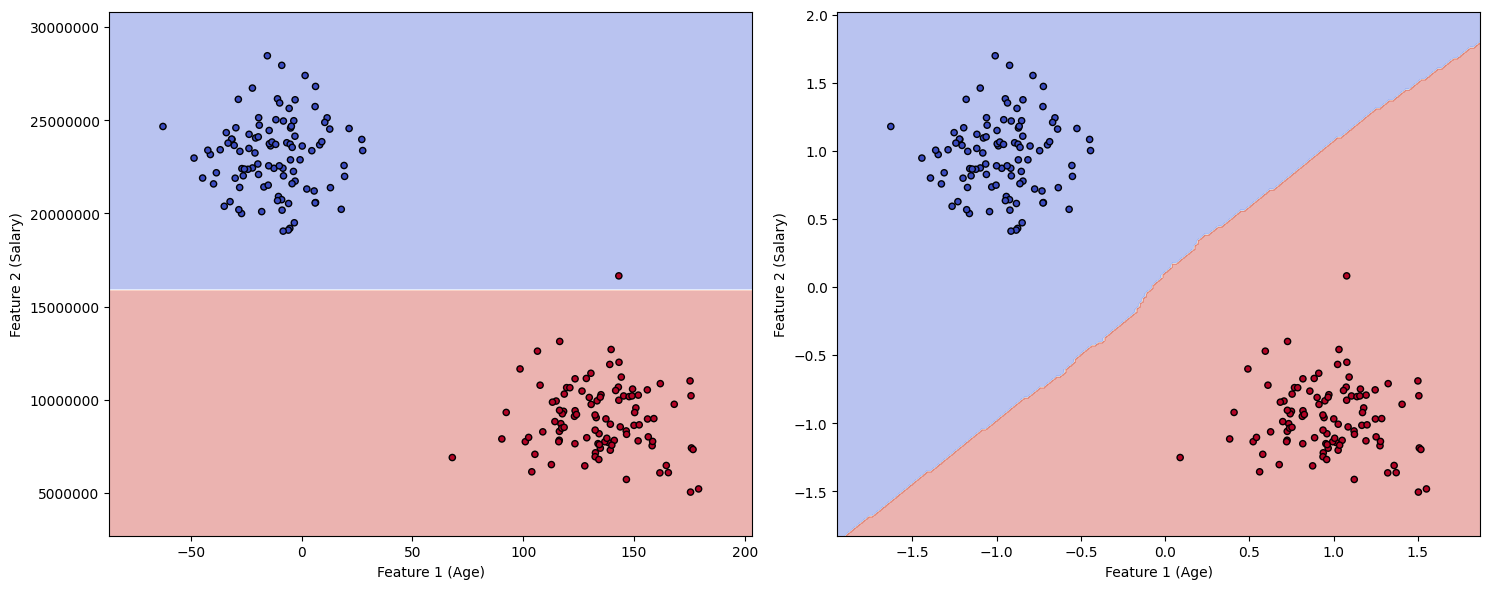

In [7]:
# T01_07.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

# 스케일이 다른 가상 데이터 생성
X_unscaled, y = make_blobs(n_samples=200, centers=2, n_features=2, cluster_std=1.0, random_state=42) # ①
X_unscaled[:, 0] = X_unscaled[:, 0] * 20 + 40 # ②
X_unscaled[:, 1] = X_unscaled[:, 1] * 2000000 + 5000000 # ③

# 데이터 스케일링(표준화)
scaler = StandardScaler() # ④
X_scaled = scaler.fit_transform(X_unscaled) # ⑤

# 결정경계를 시각화하는 함수
def plot_decision_boundary(X, y, model, title, ax): # ⑥
  x_min, x_max = X[:, 0].min() - (X[:, 0].max() - X[:, 0].min())*0.1, \
                 X[:, 0].max() + (X[:, 0].max() - X[:, 0].min())*0.1 # ⑦
  y_min, y_max = X[:, 1].min() - (X[:, 1].max() - X[:, 1].min())*0.1, \
                X[:, 1].max() + (X[:, 1].max() - X[:, 1].min())*0.1 # ⑧

  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                       np.linspace(y_min, y_max, 200)) # ⑨

  Z = model.predict(np.c_[xx.ravel(), yy.ravel()]) # ⑩
  Z = Z.reshape(xx.shape) # ⑪

  ax.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)
  ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.coolwarm)
  ax.set_xlabel("Feature 1 (Age)")
  ax.set_ylabel("Feature 2 (Salary)")

# 모델 학습 및 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 스케일링을 하지 않은 데이터로 학습
knn_unscaled = KNeighborsClassifier() # ⑫
knn_unscaled.fit(X_unscaled, y) # ⑬
plot_decision_boundary(X_unscaled, y, knn_unscaled,
                       "스케일링 전(Unscaled) 결정경계", axes[0]) # ⑭
axes[0].ticklabel_format(style='plain', axis='y') # ⑮

# 스케일링을 한 데이터로 학습
knn_scaled = KNeighborsClassifier() # ⑯
knn_scaled.fit(X_scaled, y) # ⑰
plot_decision_boundary(X_scaled, y, knn_scaled,
                       "스케일링 후(Scaled) 결정경계", axes[1]) # ⑱
plt.tight_layout()
plt.show()

In [8]:
# Q01_01.py
import pandas as pd
import seaborn as sns

df = sns.load_dataset('taxis') # ①
print(df.head()) # ②
print(df.info()) # ③

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [9]:
# Q01_02.py
# 1. datetime 타입 변환
df['pickup'] = pd.to_datetime(df['pickup']) # ①

# 2. 파생 변수 생성
df['year'] = df['pickup'].dt.year # ②
df['month'] = df['pickup'].dt.month
df['day'] = df['pickup'].dt.day
df['hour'] = df['pickup'].dt.hour # ③
df['weekday'] = df['pickup'].dt.weekday

# 변환 후 데이터 확인
print(df[['pickup', 'year', 'month', 'day', 'hour', 'weekday']].head()) # ④

               pickup  year  month  day  hour  weekday
0 2019-03-23 20:21:09  2019      3   23    20        5
1 2019-03-04 16:11:55  2019      3    4    16        0
2 2019-03-27 17:53:01  2019      3   27    17        2
3 2019-03-10 01:23:59  2019      3   10     1        6
4 2019-03-30 13:27:42  2019      3   30    13        5


In [10]:
# Q01_03.py
from sklearn.model_selection import train_test_split

# 특성(Feature)과 타겟(Target) 분리
X = df.drop(['pickup', 'dropoff', 'fare', 'total', 'tip', 'tolls'], axis=1) # ①
y = df['fare'] # ②

# 수치형 컬럼만 선택
X = X.select_dtypes(include=['number']) # ③

# 학습용과 테스트용으로 분리(8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # ④

# 분리된 데이터의 크기(Shape) 확인
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}") # ⑤

X_train shape: (5146, 7)
X_test shape: (1287, 7)
y_train shape: (5146,)
y_test shape: (1287,)
